### The geometric object (with text extraction and model variants)

Fix an observed document/input \(X\). In the OBBA example, \(X\) is a PDF whose text is parsed into a few headline targets (e.g., deficit reduction and uninsured counts) plus supporting prose about mechanisms and uncertainty.

We treat the **parameter space** as two continuous coordinates \((\Delta,\beta)\in\mathbb R^2\):

- \(\Delta\): a Medicaid alternative-specific-constant (ASC) shift, interpreted as a procedural-burden / verification-friction wedge,
- \(\beta\): a responsiveness scaling parameter in the discrete-choice system.

We also include a **discrete model-variant coordinate** (“choice-set regime”)

$$
\text{cs}\in\{\text{full},\text{restricted}\}.
$$

Each value of `cs` defines a different *sheet* (a different version of the model), motivated by the HISIM2-style idea that choice sets may be restricted “to maintain realism while keeping computing time manageable.” Formally, you can think of `cs` as part of the model specification that determines which alternatives enter the logit choice problem.

Define the toy model map

$$
\Phi_{\text{cs}}:\underbrace{\mathbb R^2}_{(\Delta,\beta)} \to \underbrace{\mathbb R^2}_{(\text{Def},\,U)},
\qquad
(\Delta,\beta)\mapsto \big(\text{Def}(\Delta,\beta;\text{cs}),\ U(\Delta,\beta;\text{cs})\big),
$$

where:
- \(\text{Def}\) is the deficit reduction over 2025–2034 (in \$ billions),
- \(U\) is the increase in uninsured in 2034 (in millions).

**Assumptions as subsets.**  
Restrictions like \(\beta\in[\underline\beta,\overline\beta]\), \(\Delta\in[\underline\Delta,\overline\Delta]\), or “use the restricted choice set” correspond to restricting attention to a subset

$$
S \subset \mathbb R^2 \times \{\text{full},\text{restricted}\}.
$$

**Attainable region.**  
In outcome space, the set of implied budget outcomes is the image

$$
\Phi(S) \subset \mathbb R^2,
$$

which we visualize as an attainable region in \((\text{Def},U)\)-space.

**Fibers / level sets.**  
A “fiber” in this geometry is a level set of the map. For example,

$$
\{(\Delta,\beta):\text{Def}(\Delta,\beta)=317\}
$$

is a curve (contour) in \((\Delta,\beta)\)-space. This is the geometric analog of the fiber/projection story: assumptions restrict the parameter space, and the induced set of possible outcomes is the image of that restricted set under \(\Phi\).

---

### Minimal formulas (what the code computes)

**Toy logit choice probabilities.**  
For alternatives \(h\) in the choice set implied by \(\text{cs}\),

$$
P_{\Delta,\beta,\text{cs}}(h) \propto \exp\big(\beta V(h) + \delta(h)\big),
\quad \text{with} \quad \delta(\text{Medicaid})\leftarrow \delta(\text{Medicaid})+\Delta.
$$

**Level of Medicaid losses (needs a denominator).**  
Given a denominator \(N_{\text{subj},2034}\) (affected population in 2034 absent policy),

$$
N_{\text{loss},2034}(\Delta,\beta)=\big(1-P(\text{Medicaid})\big)\,N_{\text{subj},2034}.
$$

**Toy calibrated budget identity.**  
Let \(s_{\text{ppy}}\) denote a calibrated savings-per-person-year parameter, and let “ramp years” be the policy-window multiplier. Then

$$
\text{Def}(\Delta,\beta)=s_{\text{ppy}}\cdot N_{\text{loss},2034}(\Delta,\beta)\cdot (\text{ramp years}).
$$

**Uninsured in 2034.**  
Let \(\Pr(\text{Uninsured}\mid \text{Leave Medicaid})\) be implied by the choice probabilities. Then

$$
U(\Delta,\beta)=\Pr(\text{Uninsured}\mid \text{Leave Medicaid})\cdot N_{\text{loss},2034}(\Delta,\beta).
$$


Extracted OBBA 71119 (from PDF text):
  total lose Medicaid 2034 (m): 5.555
  uninsured increase 2034 (m): 5.300
  uninsured share among losers: 0.954095
  deficit reduction 2025–2034 ($B): 317.0

Toy accounting calibration:
  s_ppy = 8,152 $ per person-year losing Medicaid

Formulas used in the demo:
  N_loss_2034(m) = (1 - P_post(Medicaid)) * N_subject_2034(m)
  Deficit($B) = [s_ppy * (N_loss_2034*1e6) * 7.0] / 1e9
  Uninsured_2034(m) = Pr(Uninsured | Leave Medicaid) * N_loss_2034(m)

Using N_subject_2034_m=15.0, target P_post(Medicaid) = 0.629667

(HISIM PDF not found locally; skipping tagging.)

Calibrated substitute accessibility shift (applied to ESI & Nongroup ASCs):
  sub_shift = -4.040705
  DELTAS_CAL = {'Medicaid': 2.0, 'Uninsured': 0.0, 'ESI': -3.540704518556595, 'Nongroup': -3.8407045185565947}


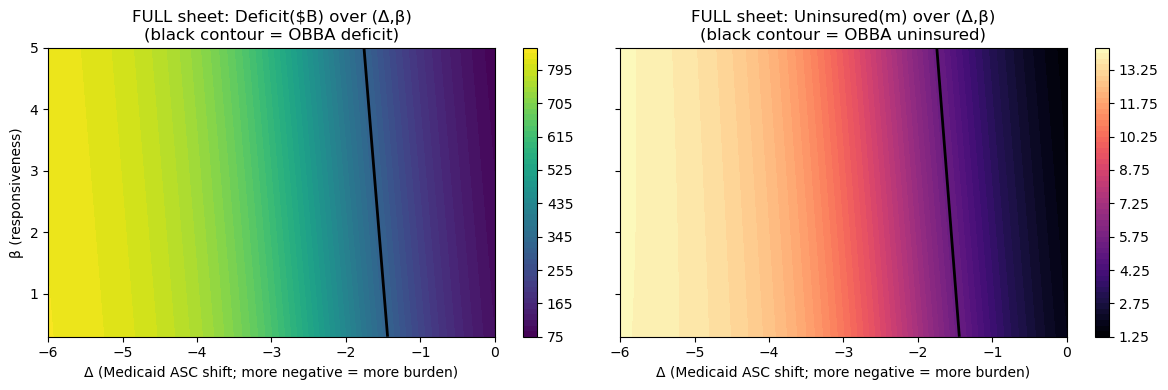

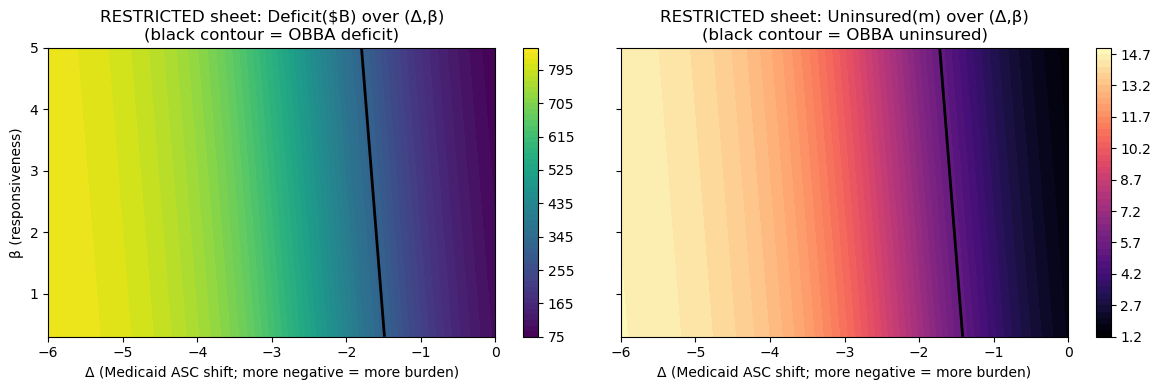

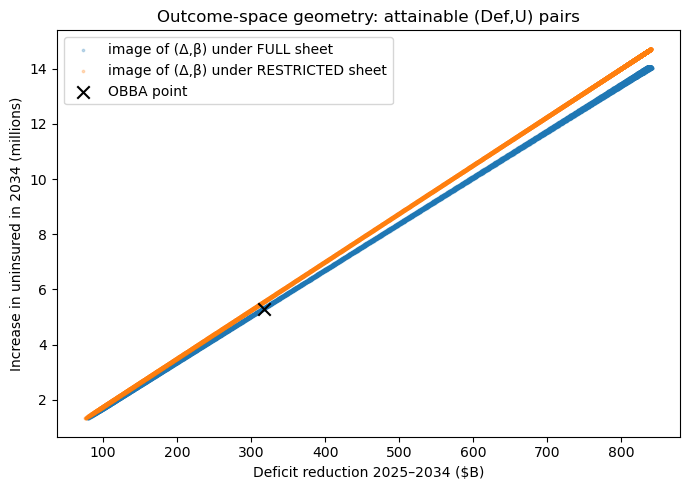


Saved plots:
  heatmaps_full.png
  heatmaps_restricted.png
  geometry_outcome_space_attainable_regions.png


In [1]:
"""
Geometry demo (toy, OBBA 71119) with heatmaps + optional text tagging.

- Reads OBBA supplemental PDF from disk (no download).
- Extracts Section 71119 block and headline numbers.
- Optionally reads HISIM2 PDF and tags "gory" sentences (keyword or Transformers).
- Defines a toy map Φ_cs : (Δ, β) -> (Def, U) for cs in {full, restricted}.
- Visualizes geometry:
  (i) parameter-space heatmaps (Def and U over (Δ,β))
  (ii) outcome-space attainable regions (images of the grid under Φ_cs)

This is NOT HISIM2 and does NOT reproduce CBO scoring.
It is an auditable illustration of: assumptions-as-coordinates -> model map -> geometry of outcomes.
"""

import re
from pathlib import Path

import numpy as np
import pdfplumber
import matplotlib.pyplot as plt

# ============================================================
# 0) CONFIG
# ============================================================

# Local PDFs
OBBA_PDF = Path("PL-119-21-Medicaid _0.pdf")   # required
HISIM_PDF = Path("57205-HISIM.pdf")            # optional

# Whether to show plots interactively (in addition to saving PNGs)
SHOW_PLOTS = True

# Whether to try Transformers (falls back to keyword tagging if not available)
USE_TRANSFORMERS = True

# Budget-window ramp approximation (transparent approximation)
RAMP_EQUIV_YEARS = 7.0

# Denominator mapping level->share:
#   N_loss_2034(m) = (1 - P_post(Medicaid)) * N_subject_2034(m)
N_subject_2034_m = 15.0  # choose and document what this means

# Discrete choice "coordinate system" knobs
CONSUMPTION_Y = 35000.0
DELTAS_BASE = {"Medicaid": 2.0, "Uninsured": 0.0, "ESI": 0.5, "Nongroup": 0.2}
CHOICE_SET_FULL = ("Medicaid", "Uninsured", "ESI", "Nongroup")
CHOICE_SET_RESTRICTED = ("Medicaid", "Uninsured")  # choice-set restriction "sheet"

# Parameter grid for geometry
DELTA_GRID = np.linspace(0.0, -6.0, 121)   # Δ: Medicaid ASC shift (more negative = more burden)
BETA_GRID  = np.linspace(0.3, 5.0, 121)    # β: responsiveness scaling

# Toy health spending states (only affects relative attractiveness of alternatives)
RNG_SEED = 0
S = 14
UNINS_CAP = 2000.0
UNINS_COLLECTION_RATE = 0.2
MEDICAID_OOP_RATE = 0.05
ALPHA_BAD_DEBT = 0.25


# ============================================================
# 1) PDF utilities + OBBA extraction
# ============================================================

def pdf_to_text(pdf_path, max_pages=None):
    parts = []
    with pdfplumber.open(pdf_path) as pdf:
        pages = pdf.pages[:max_pages] if max_pages else pdf.pages
        for p in pages:
            parts.append(p.extract_text() or "")
    return "\n".join(parts)

def find_block(text, start_pat, end_pat=None, max_len=25000):
    m = re.search(start_pat, text, flags=re.IGNORECASE)
    if not m:
        return None
    start = m.start()
    if end_pat:
        n = re.search(end_pat, text[start:], flags=re.IGNORECASE)
        end = start + n.start() if n else min(len(text), start + max_len)
    else:
        end = min(len(text), start + max_len)
    return text[start:end]

def extract_float(pattern, s):
    m = re.search(pattern, s, flags=re.IGNORECASE | re.DOTALL)
    return float(m.group(1)) if m else None


assert OBBA_PDF.exists(), f"Missing OBBA PDF: {OBBA_PDF.resolve()}"
obba_text = pdf_to_text(OBBA_PDF)

block_71119 = find_block(
    obba_text,
    start_pat=r"Community Engagement Requirements\.\s*Section\s*71119",
    end_pat=r"Other Medicaid-Related Effects|Uncertainty"
)
if block_71119 is None:
    raise ValueError("Could not locate 71119 block. Adjust start/end regex.")

# Parse headline numbers used in the demo
N_fail_2034 = extract_float(r"about\s+(\d+(\.\d+)?)\s+million\s+in\s+2034.*?will lose\s+coverage", block_71119)
N_admin_2034 = extract_float(r"about\s+(\d+(\.\d+)?)\s+million\s+additional.*?lose Medicaid coverage in\s+2034", block_71119)
p_keep_pct = extract_float(r"about\s+(\d+(\.\d+)?)\s+percent.*?will keep their Medicaid\s+coverage", block_71119)
uninsured_2034 = extract_float(r"increase by\s+(\d+(\.\d+)?)\s+million\s+in\s+2034", block_71119)
deficit_red_B = extract_float(r"decrease deficits by\s+\$?(\d+(\.\d+)?)\s+billion", block_71119)

p_keep = p_keep_pct / 100.0
N_loss_total_2034 = (1 - p_keep) * N_fail_2034 + N_admin_2034
uninsured_share_among_losers_obba = uninsured_2034 / N_loss_total_2034

print("\nExtracted OBBA 71119 (from PDF text):")
print(f"  total lose Medicaid 2034 (m): {N_loss_total_2034:.3f}")
print(f"  uninsured increase 2034 (m): {uninsured_2034:.3f}")
print(f"  uninsured share among losers: {uninsured_share_among_losers_obba:.6f}")
print(f"  deficit reduction 2025–2034 ($B): {deficit_red_B:.1f}")

# Calibrate toy savings-per-person-year so baseline matches OBBA
s_ppy = (deficit_red_B * 1e9) / (N_loss_total_2034 * 1e6 * RAMP_EQUIV_YEARS)
print(f"\nToy accounting calibration:")
print(f"  s_ppy = {s_ppy:,.0f} $ per person-year losing Medicaid")

print("\nFormulas used in the demo:")
print("  N_loss_2034(m) = (1 - P_post(Medicaid)) * N_subject_2034(m)")
print(f"  Deficit($B) = [s_ppy * (N_loss_2034*1e6) * {RAMP_EQUIV_YEARS}] / 1e9")
print("  Uninsured_2034(m) = Pr(Uninsured | Leave Medicaid) * N_loss_2034(m)")

target_P_medicaid_post = 1.0 - (N_loss_total_2034 / N_subject_2034_m)
print(f"\nUsing N_subject_2034_m={N_subject_2034_m:.1f}, target P_post(Medicaid) = {target_P_medicaid_post:.6f}")


# ============================================================
# 2) Optional HISIM2 "gory statement" tagging (keyword or Transformers)
# ============================================================

def split_sentences(s):
    s = re.sub(r"\s+", " ", s).strip()
    return re.split(r"(?<=[\.\?\!])\s+", s)

def keyword_tag(sent):
    t = sent.lower()
    if "alternative-specific constant" in t or "alternative specific constant" in t:
        return "ASC (access/awareness/stigma)"
    if "restricted the choice sets" in t or ("choice sets" in t and "restricted" in t):
        return "choice-set restriction"
    if "uninsured people are not fully exposed" in t or "charity care" in t or "never collected" in t or "bankruptcy" in t:
        return "uninsured financial exposure"
    if "scaling factor" in t and "responsiveness" in t:
        return "scaling beta / responsiveness"
    if "calibration" in t and ("targets" in t or "minimize" in t):
        return "calibration targets"
    return None

if HISIM_PDF.exists():
    hisim_text = pdf_to_text(HISIM_PDF, max_pages=60)
    hisim_sents = [x for x in split_sentences(hisim_text) if len(x) > 80]

    transformer_pipeline = None
    if USE_TRANSFORMERS:
        try:
            from transformers import pipeline
            transformer_pipeline = pipeline(
                "zero-shot-classification",
                model="valhalla/distilbart-mnli-12-1"
            )
        except Exception as e:
            print("\nTransformers unavailable; falling back to keyword tagging.\n", e)
            transformer_pipeline = None

    print("\n=== HISIM2: example 'gory' sentences (tagged) ===")
    labels = [
        "ASC (access/awareness/stigma)",
        "choice-set restriction",
        "uninsured financial exposure",
        "scaling beta / responsiveness",
        "calibration targets",
        "other"
    ]

    hits = []
    for s in hisim_sents:
        if transformer_pipeline is not None:
            out = transformer_pipeline(s, candidate_labels=labels, multi_label=False)
            tag = out["labels"][0]
            score = out["scores"][0]
            if tag != "other" and score > 0.6:
                hits.append((tag, score, s))
        else:
            tag = keyword_tag(s)
            if tag:
                hits.append((tag, None, s))

    # Print a few per tag
    by_tag = {}
    for tag, score, sent in hits:
        by_tag.setdefault(tag, []).append((score, sent))

    for tag in sorted(by_tag.keys()):
        print(f"\n[{tag}]")
        for score, sent in by_tag[tag][:3]:
            if score is not None:
                print(f"- (score={score:.2f}) {sent}")
            else:
                print(f"- {sent}")
else:
    print("\n(HISIM PDF not found locally; skipping tagging.)")


# ============================================================
# 3) Toy discrete choice model + map Φ
# ============================================================

rng = np.random.default_rng(RNG_SEED)
p_state = np.ones(S) / S
H = np.sort(rng.lognormal(mean=8.0, sigma=0.7, size=S))

def build_costs(H, medicaid_oop_rate=0.05, unins_cap=2000.0, unins_collection_rate=0.2):
    oop_med = medicaid_oop_rate * H
    oop_unins = np.minimum(H, unins_cap) + unins_collection_rate * np.maximum(0, H - unins_cap)
    baddebt = (1 - unins_collection_rate) * np.maximum(0, H - unins_cap)
    return oop_med, oop_unins, baddebt

def softmax(u):
    u = np.array(u, dtype=float)
    u = u - u.max()
    e = np.exp(u)
    return e / e.sum()

def V_alt(consumption, alt):
    oop_med, oop_unins, baddebt = build_costs(H, MEDICAID_OOP_RATE, UNINS_CAP, UNINS_COLLECTION_RATE)

    if alt == "Medicaid":
        net = consumption - oop_med
        return float(np.sum(p_state * np.log(np.maximum(net, 1.0))))
    if alt == "Uninsured":
        net = consumption - oop_unins - ALPHA_BAD_DEBT * baddebt
        return float(np.sum(p_state * np.log(np.maximum(net, 1.0))))
    if alt == "ESI":
        prem = 2500.0
        oop = 0.15 * H
        net = consumption - prem - oop
        return float(np.mean(np.log(np.maximum(net, 1.0))))
    if alt == "Nongroup":
        prem = 4500.0
        oop = 0.20 * H
        net = consumption - prem - oop
        return float(np.mean(np.log(np.maximum(net, 1.0))))
    raise ValueError(alt)

def choice_probs(consumption, beta_scale, deltas, choice_set):
    Us = []
    for alt in choice_set:
        Us.append(beta_scale * V_alt(consumption, alt) + deltas.get(alt, 0.0))
    p = softmax(Us)
    return dict(zip(choice_set, p))

def uninsured_among_leavers(p_post):
    leave = 1.0 - p_post.get("Medicaid", 0.0)
    if leave <= 1e-15:
        return 0.0
    return p_post.get("Uninsured", 0.0) / leave

def implied_budget_and_uninsured(P_medicaid_post, uninsured_among_leavers_val):
    N_loss_2034_m = (1.0 - P_medicaid_post) * N_subject_2034_m
    Uninsured_2034_m = uninsured_among_leavers_val * N_loss_2034_m
    deficit_dollars = s_ppy * (N_loss_2034_m * 1e6) * RAMP_EQUIV_YEARS
    deficit_B = deficit_dollars / 1e9
    return deficit_B, Uninsured_2034_m, N_loss_2034_m


# ============================================================
# 4) Calibrate substitute accessibility so FULL sheet matches OBBA uninsured-share-among-losers
# ============================================================

def calibrate_Delta_for_target_P(target_P, consumption, beta_scale, deltas_base, choice_set, lo=-200.0, hi=0.0):
    def Pmed(Delta):
        d = dict(deltas_base)
        d["Medicaid"] = deltas_base["Medicaid"] + Delta
        return choice_probs(consumption, beta_scale, d, choice_set)["Medicaid"]

    f_lo = Pmed(lo) - target_P
    f_hi = Pmed(hi) - target_P
    if f_lo * f_hi > 0:
        return lo if abs(f_lo) < abs(f_hi) else hi

    a, b = lo, hi
    for _ in range(300):
        mid = 0.5 * (a + b)
        f_mid = Pmed(mid) - target_P
        if abs(f_mid) < 1e-10:
            return mid
        if f_mid > 0:
            b = mid
        else:
            a = mid
    return 0.5 * (a + b)

def calibrate_sub_shift_for_uninsured_share(target_uninsured_share, consumption, beta_scale, deltas_base, choice_set):
    lo, hi = -30.0, 0.0

    def g(t):
        deltas = dict(deltas_base)
        if "ESI" in deltas: deltas["ESI"] += t
        if "Nongroup" in deltas: deltas["Nongroup"] += t

        Delta = calibrate_Delta_for_target_P(target_P_medicaid_post, consumption, beta_scale, deltas, choice_set)
        deltas_post = dict(deltas)
        deltas_post["Medicaid"] += Delta
        p_post = choice_probs(consumption, beta_scale, deltas_post, choice_set)
        return uninsured_among_leavers(p_post) - target_uninsured_share

    g_lo, g_hi = g(lo), g(hi)
    if g_lo * g_hi > 0:
        return lo if abs(g_lo) < abs(g_hi) else hi

    a, b = lo, hi
    for _ in range(250):
        mid = 0.5 * (a + b)
        gm = g(mid)
        if abs(gm) < 1e-8:
            return mid
        if gm > 0:
            a = mid
        else:
            b = mid
    return 0.5 * (a + b)

sub_shift = calibrate_sub_shift_for_uninsured_share(
    target_uninsured_share=uninsured_share_among_losers_obba,
    consumption=CONSUMPTION_Y,
    beta_scale=1.0,
    deltas_base=DELTAS_BASE,
    choice_set=CHOICE_SET_FULL
)

DELTAS_CAL = dict(DELTAS_BASE)
DELTAS_CAL["ESI"] += sub_shift
DELTAS_CAL["Nongroup"] += sub_shift

print("\nCalibrated substitute accessibility shift (applied to ESI & Nongroup ASCs):")
print(f"  sub_shift = {sub_shift:.6f}")
print(f"  DELTAS_CAL = {DELTAS_CAL}")


# ============================================================
# 5) Evaluate Φ over the grid for each sheet
# ============================================================

def eval_map_over_grid(choice_set, deltas_base):
    Def = np.zeros((len(BETA_GRID), len(DELTA_GRID)))
    Un  = np.zeros_like(Def)

    for i, beta in enumerate(BETA_GRID):
        for j, Delta in enumerate(DELTA_GRID):
            deltas_post = dict(deltas_base)
            deltas_post["Medicaid"] = deltas_base["Medicaid"] + Delta
            deltas_post = {k: v for k, v in deltas_post.items() if k in choice_set}

            p_post = choice_probs(CONSUMPTION_Y, beta, deltas_post, choice_set)
            pm = p_post.get("Medicaid", np.nan)
            ual = uninsured_among_leavers(p_post)

            deficit_B, uninsured_m, _ = implied_budget_and_uninsured(pm, ual)
            Def[i, j] = deficit_B
            Un[i, j] = uninsured_m

    return Def, Un

Def_full, Un_full = eval_map_over_grid(CHOICE_SET_FULL, DELTAS_CAL)

DELTAS_CAL_RESTRICTED = {k: v for k, v in DELTAS_CAL.items() if k in CHOICE_SET_RESTRICTED}
Def_res, Un_res = eval_map_over_grid(CHOICE_SET_RESTRICTED, DELTAS_CAL_RESTRICTED)

D, B = np.meshgrid(DELTA_GRID, BETA_GRID)


# ============================================================
# 6) Plot heatmaps (filled contours) + outcome-space attainable regions
# ============================================================

def heatmap_pair(D, B, Z1, Z2, title_left, title_right, fname):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

    im1 = ax[0].contourf(D, B, Z1, levels=50, cmap="viridis")
    fig.colorbar(im1, ax=ax[0])
    ax[0].contour(D, B, Z1, levels=[deficit_red_B], colors="black", linewidths=2)
    ax[0].set_title(title_left)
    ax[0].set_xlabel("Δ (Medicaid ASC shift; more negative = more burden)")
    ax[0].set_ylabel("β (responsiveness)")

    im2 = ax[1].contourf(D, B, Z2, levels=50, cmap="magma")
    fig.colorbar(im2, ax=ax[1])
    ax[1].contour(D, B, Z2, levels=[uninsured_2034], colors="black", linewidths=2)
    ax[1].set_title(title_right)
    ax[1].set_xlabel("Δ (Medicaid ASC shift; more negative = more burden)")

    fig.tight_layout()
    fig.savefig(fname, dpi=200)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

heatmap_pair(
    D, B, Def_full, Un_full,
    "FULL sheet: Deficit($B) over (Δ,β)\n(black contour = OBBA deficit)",
    "FULL sheet: Uninsured(m) over (Δ,β)\n(black contour = OBBA uninsured)",
    "heatmaps_full.png"
)

heatmap_pair(
    D, B, Def_res, Un_res,
    "RESTRICTED sheet: Deficit($B) over (Δ,β)\n(black contour = OBBA deficit)",
    "RESTRICTED sheet: Uninsured(m) over (Δ,β)\n(black contour = OBBA uninsured)",
    "heatmaps_restricted.png"
)

# Outcome-space attainable regions
pts_full = np.column_stack([Def_full.ravel(), Un_full.ravel()])
pts_res  = np.column_stack([Def_res.ravel(),  Un_res.ravel()])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pts_full[:, 0], pts_full[:, 1], s=3, alpha=0.25, label="image of (Δ,β) under FULL sheet")
ax.scatter(pts_res[:, 0],  pts_res[:, 1],  s=3, alpha=0.25, label="image of (Δ,β) under RESTRICTED sheet")
ax.scatter([deficit_red_B], [uninsured_2034], s=80, marker="x", color="black", label="OBBA point")

ax.set_xlabel("Deficit reduction 2025–2034 ($B)")
ax.set_ylabel("Increase in uninsured in 2034 (millions)")
ax.set_title("Outcome-space geometry: attainable (Def,U) pairs")
ax.legend()
fig.tight_layout()
fig.savefig("geometry_outcome_space_attainable_regions.png", dpi=200)
if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)

print("\nSaved plots:")
print("  heatmaps_full.png")
print("  heatmaps_restricted.png")
print("  geometry_outcome_space_attainable_regions.png")